### Figure 4F2. Does **more time spent** on long theta or remote theta content help improve choice accuracy on top of the change of mind decision?

Oct 31, 2025

In [1]:
%reload_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [4]:
from spyglass.shijiegu.changeOfMind_figures.figure4 import (long_theta_count_per_day, intersection,
            return_com_theta_length_remote_feature)
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_choice_animal, trial_to_features
from spyglass.shijiegu.Analysis_SGU import ChangeofMind

from spyglass.shijiegu.changeOfMind import nodes
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.changeOfMind_remote import do_GLM_subprocess

from spyglass.shijiegu.changeOfMind_remote_interval import save_remote_animal, load_remote_animal

[2025-10-31 14:35:09,785][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[14:35:18][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:35:18][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:35:18][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:35:19][WARNING] Spyglass: Deprecation: this class has b

In [409]:
list_of_days_animals, encoding_set_animals, classifier_param_name_animals, seq_animals, learning_flag = {}, {}, {}, {}, {}

In [410]:
animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
learning_flag[animal] = [1,1,1,1,0] #denote for each day, if it is a learning day
encoding_set_animals[animal]  = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110','20240113']
learning_flag[animal] = [1,1,1,1,1,0,0] #denote for each day, if it is a learning day

encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'rev2'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
learning_flag[animal] = [1,1,1,1,1,1,0,0,0] #denote for each day, if it is a learning day
encoding_set_animals[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'seq2'

animal = 'julio'
#list_of_days_animals[animal] = ['20230808','20230809','20230810','20230811']
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
learning_flag[animal] = [1 for d in ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806']] #denote for each day, if it is a learning day
learning_flag[animal] += [0 for d in ['20230807','20230808','20230809','20230810','20230811']]

encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107','20231108','20231109','20231111']
learning_flag[animal] = [1 for d in ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107']]
learning_flag[animal] += [0 for d in ['20231108','20231109','20231111']]

encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'rev2'

### Simple conditioning

In [221]:
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta, ChangeofMindRemoteTheta, TrialChoice

In [8]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'

In [423]:
success = {}
animals = ["eliot","molly","lewis","julio","klein"] #"julio","klein"]#,"julio","klein"]

use_1d = 1
proportion = 0.1
for animal in animals:

    # loop through all trials
    list_of_days = list_of_days_animals[animal]
    learning_flag_days = learning_flag[animal]
    
    remote_theta_time = []
    long_theta_time = []
    com_num = [] #number of change of mind
    reward = []
    learning = []

    for day_ind in range(len(list_of_days)):
        day = list_of_days[day_ind]
        learning_flag_day = learning_flag_days[day_ind]
    
        nwb_file_name = animal.lower() + day + '.nwb'
        nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)
        print(nwb_copy_file_name)
        session_interval, position_interval = runSessionNames(nwb_copy_file_name)
            
        q = {"proportion": 0.1,
             "delta_t_minus":5, "delta_t_plus":5,
             "max_flag":1}
    
        q["nwb_file_name"] = nwb_copy_file_name
    
        # change of mind trial with theta on this day
        for session_name in session_interval:
            q["epoch"] = session_name[:2]
            long_df = ChangeofMindTheta().fetch1_dataframe(q)         # trials with long theta
            remote_df = ChangeofMindRemoteTheta().fetch1_dataframe(q) # trials with remote theta for now
    
            # change of mind trials
            theta_df_subset = long_df[long_df.change_of_mind]
    
            # theta trials
            for trialID in theta_df_subset.index:
                
                
                # find all long theta intervals on that trial
                if long_df.loc[trialID].long_theta:
                    long_theta_intervals = long_df.loc[trialID].long_theta_intervals
                    sum_long = np.sum([intvl[1]-intvl[0] for intvl in long_theta_intervals])
                else:
                    sum_long = 0
                

                # find all remote intervals on that trial
                if remote_df.loc[trialID].has_remote_interval:
                    remote_theta_intervals = remote_df.loc[trialID].remote_interval
                    sum_remote = np.sum([intvl[1]-intvl[0] for intvl in remote_theta_intervals])
                else:
                    sum_remote = 0
                

                if sum_long == 0 and sum_remote == 0:
                    continue
                    # error, because there should be either a long theta event or remote event
                    #continue

                # correct or not
                # find change of mind number on this trial
                com_num.append(long_df.loc[trialID].CoMNum_by_arm)
                reward.append(theta_df_subset.loc[trialID].rewardNum == 2)
                long_theta_time.append(sum_long)
                remote_theta_time.append(sum_remote)
                learning.append(learning_flag_day)


    data = {"com_num": com_num, "long_theta_time":long_theta_time,
            "remote_theta_time":remote_theta_time, "reward":reward,
            "learning": learning,
           }

    output_path = os.path.join(output_folder,f"{animal}_figure4Fb") #os.join(output_folder,plot_data_filename)
    with open(output_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved.")
        
    success[animal] = 1


eliot20221018_.nwb
eliot20221019_.nwb
eliot20221020_.nwb
eliot20221021_.nwb
eliot20221022_.nwb
eliot20221023_.nwb
eliot20221024_.nwb
eliot20221025_.nwb
eliot20221026_.nwb
Data successfully pickled and saved.
molly20220416_.nwb
molly20220417_.nwb
molly20220418_.nwb
molly20220419_.nwb
molly20220420_.nwb
Data successfully pickled and saved.
lewis20240105_.nwb
lewis20240106_.nwb
lewis20240107_.nwb
lewis20240108_.nwb
lewis20240109_.nwb
lewis20240110_.nwb
lewis20240113_.nwb
Data successfully pickled and saved.
julio20230731_.nwb
julio20230801_.nwb
julio20230802_.nwb
julio20230803_.nwb
julio20230804_.nwb
julio20230805_.nwb
julio20230806_.nwb
julio20230807_.nwb
julio20230808_.nwb
julio20230809_.nwb
julio20230810_.nwb
julio20230811_.nwb
Data successfully pickled and saved.
klein20231101_.nwb
klein20231102_.nwb
klein20231103_.nwb
klein20231104_.nwb
klein20231105_.nwb
klein20231106_.nwb
klein20231107_.nwb
klein20231108_.nwb
klein20231109_.nwb
klein20231111_.nwb
Data successfully pickled and saved

### debug start

In [276]:
loaded_data = load_remote_animal(
        animal, list_of_days_animals[animal],
        encoding_set_animals[animal],
        classifier_param_name_animals[animal],
        proportion = proportion, use_1d = use_1d)
    
(all_info_animal, info_animal,
     time_intervals_animal, arm_identities_animal
        ) = (loaded_data['all_info_animal'], loaded_data['info_animal'],
             loaded_data['time_intervals_animal'], loaded_data['arm_identities_animal'])

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/eliot_2Dheadspeed_above_4_andlowmua_default_decoding_gpu_4armMaze_20221018_20221026_p0.1_use1d1.pkl':


In [287]:
ind = 24
print(info_animal[ind])
print(arm_identities_animal[ind])
print(time_intervals_animal[ind][0][0],time_intervals_animal[ind][0][-1])

['eliot20221021_.nwb', '04_Seq2Session2', [29, 29, 29, 29, 29, 29]]
[2, 2, 2, 2, 2, 2]
1666389670.94235 1666389670.99235


In [318]:
q = {"proportion": 0.1,
     "delta_t_minus":5, "delta_t_plus":5,
     "max_flag":1}
    
q["nwb_file_name"] = 'eliot20221021_.nwb'
    
session_name = '02_Seq2Session1'
q["epoch"] = session_name[:2]
print(q)
remote_df = ChangeofMindRemoteTheta().fetch1_dataframe(q)
long_df = ChangeofMindTheta().fetch1_dataframe(q)
theta_df = ChangeofMind().fetch1_dataframe(q)
df = pd.DataFrame((TrialChoice & q).fetch1("choice_reward"))

[2025-11-01 13:23:30,366][WARNING]: Skipped checksum for file with hash: 145544ce-9b16-2ab9-f0ac-df5a62adb5f5, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_ZXS05TLCX7.nwb


{'proportion': 0.1, 'delta_t_minus': 5, 'delta_t_plus': 5, 'max_flag': 1, 'nwb_file_name': 'eliot20221021_.nwb', 'epoch': '02'}


In [319]:
session_trial_union["20221021"]

[('04_Seq2Session2', 53),
 ('02_Seq2Session1', 55),
 ('02_Seq2Session1', 62),
 ('02_Seq2Session1', 71),
 ('04_Seq2Session2', 68),
 ('08_Seq2Session4', 78),
 ('04_Seq2Session2', 29),
 ('08_Seq2Session4', 60)]

### debug end

In [416]:
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars

In [417]:
color_by_rat = {"eliot": "C0","molly":"C2","lewis":"C4","julio":"C1","klein":"deepskyblue"}

def sd_err(arr):
    return np.std(arr)/np.sqrt(len(arr))

def plot_one_axis(data1, data2, animal_ind, ax, animal):
    std = [sd_err(data1), sd_err(data2)]
    mean = [np.mean(data1), np.mean(data2)]
    ax.bar([0 + animal_ind,
                0.3 + animal_ind],mean, yerr=std, width=0.2, color = color_by_rat[animal])
    ax.text(animal_ind - 0.05, mean[0]+std[0] + 0.1, len(data1), fontsize = 6)
    ax.text(animal_ind + 0.3 - 0.05, mean[1]+std[1] + 0.1, len(data2), fontsize = 6)
        
    table = np.array([[np.sum(data1 == 0), np.sum(data1 == 1)],[np.sum(data2 == 0), np.sum(data2 == 1)]])
    res = fisher_exact(table)
    p_value = res.pvalue
    if p_value < 0.05:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.3, np.round(p_value, 4))], ax = ax)
    return ax



Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/eliot_figure4Fb
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/molly_figure4Fb
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/lewis_figure4Fb
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/julio_figure4Fb
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/klein_figure4Fb


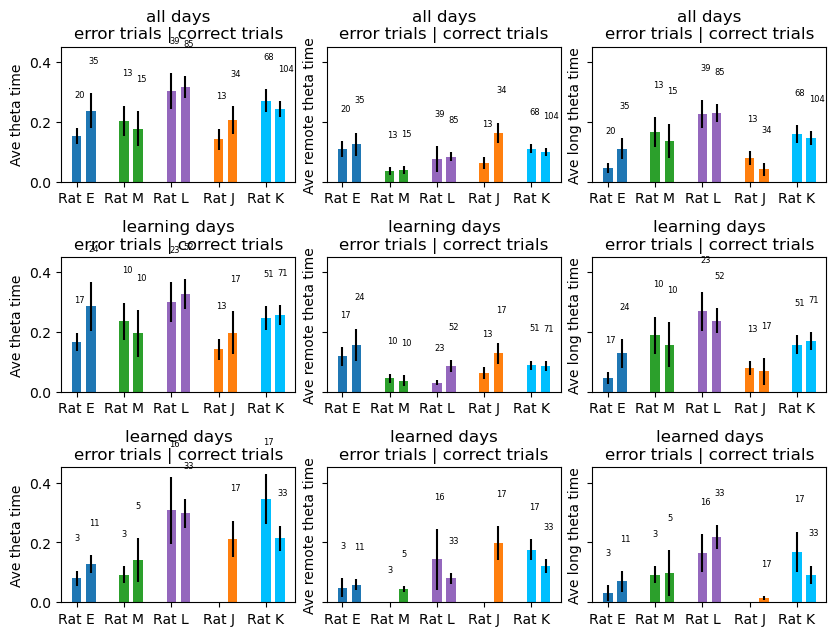

In [425]:
num_of_panels = 3
fig, axes = plt.subplots(3, num_of_panels, figsize=(3 * num_of_panels, 7),sharey = True)

animal_ind = 0
animals = ["eliot","molly","lewis","julio","klein"]
for animal in animals:
    output_path = os.path.join(output_folder,f"{animal}_figure4Fb") #os.join(output_folder,plot_data_filename)
    with open(output_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Data successfully loaded from {output_path}")

    (reward, remote_theta_time, long_theta_time, com_num, learning) = (
        loaded_data["reward"],
        loaded_data["remote_theta_time"], loaded_data["long_theta_time"],
        loaded_data["com_num"], loaded_data["learning"])
    reward = np.array(reward)
    remote_theta_time = np.array(remote_theta_time)
    long_theta_time = np.array(long_theta_time)
    learning = np.array(learning)

    for axes_row_ind in [0,1,2]: #all data, learning days, post-learning days
        if axes_row_ind == 0:
            time_error = remote_theta_time[reward == 0] + long_theta_time[reward == 0]
            time_correct = remote_theta_time[reward] + long_theta_time[reward]
            remote_time_error = remote_theta_time[reward == 0]
            remote_time_correct = remote_theta_time[reward]
            long_time_error = long_theta_time[reward == 0]
            long_time_correct = long_theta_time[reward]

        elif axes_row_ind == 1:
            time_error = remote_theta_time[np.logical_and(reward == 0, learning)] + long_theta_time[np.logical_and(reward == 0, learning)]
            time_correct = remote_theta_time[np.logical_and(reward == 1, learning)] + long_theta_time[np.logical_and(reward == 1, learning)]
            remote_time_error = remote_theta_time[np.logical_and(reward == 0, learning)]
            remote_time_correct = remote_theta_time[np.logical_and(reward == 1, learning)]
            long_time_error = long_theta_time[np.logical_and(reward == 0, learning)]
            long_time_correct = long_theta_time[np.logical_and(reward == 1, learning)]
            
        elif axes_row_ind == 2:
            nonlearning = 1 - np.array(learning)
            time_error = remote_theta_time[np.logical_and(reward == 0, nonlearning)] + long_theta_time[np.logical_and(reward == 0, nonlearning)]
            time_correct = remote_theta_time[np.logical_and(reward == 1, nonlearning)] + long_theta_time[np.logical_and(reward == 1, nonlearning)]
            remote_time_error = remote_theta_time[np.logical_and(reward == 0, nonlearning)]
            remote_time_correct = remote_theta_time[np.logical_and(reward == 1, nonlearning)]
            long_time_error = long_theta_time[np.logical_and(reward == 0, nonlearning)]
            long_time_correct = long_theta_time[np.logical_and(reward == 1, nonlearning)]
            
        # axis 1: nontheta vs theta
        ax = axes[axes_row_ind,0]
        data1, data2 = time_error, time_correct
        plot_one_axis(data1, data2, animal_ind, ax, animal)
    
        # axis 2: nontheta vs theta
        ax = axes[axes_row_ind,1]
        data1, data2 = remote_time_error, remote_time_correct
        plot_one_axis(data1, data2, animal_ind, ax, animal)

        # axis 3: nontheta vs long theta
        ax = axes[axes_row_ind,2]
        data1, data2 = long_time_error, long_time_correct
        plot_one_axis(data1, data2, animal_ind, ax, animal)
        
    animal_ind += 1

for j in range(3):
    axes_colj = axes[:,j]
    for i in range(3):
        ax = axes[i,j]
        ax.set_xticks(np.arange(len(animals)));
        ax.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
        
        #ax.set_xlim([-1,len(animals) + 1]);
        #ax.set_ylim([0.3,0.85]);

        if j == 0:
            title = "error trials | correct trials"
            ax.set_ylabel("Ave theta time")
        elif j == 1:
            title = "error trials | correct trials"
            ax.set_ylabel("Ave remote theta time")
        elif j == 2:
            title = "error trials | correct trials"
            ax.set_ylabel("Ave long theta time")
        if i == 0:
            title = "all days\n" + title
        elif i == 1:
            title = "learning days\n" + title
        elif i == 2:
            title = "learned days\n" + title
        
        ax.set_title(title)
        
    #axes.set_xlim([-0.2,len(animals)-1 + 0.5])

fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

In [380]:
import statsmodels.api as sm

### merge all animals

In [428]:
animals = ["eliot","molly","lewis","julio","klein"]

animal_ind = 0

GLM_xy = []
for animal in animals:
    output_path = os.path.join(output_folder,f"{animal}_figure4Fb") #os.join(output_folder,plot_data_filename)
    with open(output_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Data successfully loaded from {output_path}")

    (reward, remote_theta_time, long_theta_time, com_num, learning) = (
        loaded_data["reward"],
        loaded_data["remote_theta_time"], loaded_data["long_theta_time"],
        loaded_data["com_num"], loaded_data["learning"])
    reward = np.array(reward)
    remote_theta_time = np.array(remote_theta_time)
    long_theta_time = np.array(long_theta_time)
    learning = np.array(learning)
    remotexlearning = remote_theta_time * learning
    longxlearning = long_theta_time * learning
    timexlearning = (remote_theta_time + long_theta_time) * learning

    animal_category = [a == animal for a in animals]
    for ind in range(len(reward)):
        GLM_xy.append(animal_category + [
            com_num[ind],
            remote_theta_time[ind] + long_theta_time[ind],
            remote_theta_time[ind],
            long_theta_time[ind],
            learning[ind],
            timexlearning[ind],
            remotexlearning[ind],
            longxlearning[ind],
            reward[ind]])

GLM_xy = np.array(GLM_xy)

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/eliot_figure4Fb
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/molly_figure4Fb
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/lewis_figure4Fb
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/julio_figure4Fb
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/klein_figure4Fb


#### a) Mixed Linear Effect

In [436]:
## Model 1: no time or with time
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_xy[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["remote theta time"] = GLM_xy[:,(len(animals)+2)]
feature_dict["long theta time"] = GLM_xy[:,(len(animals)+3)]
feature_dict["remote time x learning"] = GLM_xy[:,(len(animals)+6)]
feature_dict["long time x learning"] = GLM_xy[:,(len(animals)+7)]

X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_xy[:,-1]

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(y,X)
ols_result1 = ols_model.fit()

print("Mixed Linear Effect \n",ols_result1.summary())

"""b) Logistic"""
logistic_model = sm.Logit(y, X)
logistic_result1 = logistic_model.fit()

# 3. View the model summary
print("Mixed Logistics \n",logistic_result1.summary())
 

Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.6596
Date:                Tue, 04 Nov 2025   Prob (F-statistic):              0.727
Time:                        22:25:05   Log-Likelihood:                -288.90
No. Observations:                 426   AIC:                             595.8
Df Residuals:                     417   BIC:                             632.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const 

### plot model parameters

In [437]:
def model2numbers(ols_result):
    coef_names = ols_result.params.keys()
    coef_est = np.array(ols_result.params)
    pvalues = ols_result.pvalues
    CI = ols_result.conf_int(alpha=0.05)
    #yerr = np.vstack((np.array(CI[0]).reshape((1,-1)), np.array(CI[1]).reshape((1,-1)))) # 2 x coefficients

    return ols_result.params, coef_names, coef_est, pvalues, CI#, yerr

10.780000000000001 0.03
10.780000000000001 0.03
10.780000000000001 0.03


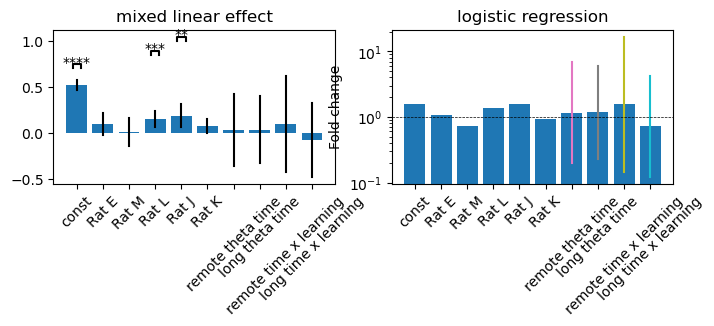

In [440]:
# 4. Create the bar graph using matplotlib

fig, axes = plt.subplots(1,2,figsize=(8, 2))

#### axis 0
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result1)
axes[0].bar(coef_names, coef_est)
for coef_name in coef_names:
    axes[0].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes[0])

axes[0].set_xticks(np.arange(len(coef_names)))
axes[0].set_xticklabels(coef_names, rotation=45)
axes[0].set_title("mixed linear effect")


#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logistic_result1)
coef_est = np.exp(coef_est)
coef_pd = np.exp(coef_pd)
CI = np.exp(CI)

axes[1].bar(coef_names, coef_est)
for coef_name in coef_names:
    axes[1].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]])

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes[1], color = 'k')

axes[1].set_xticks(np.arange(len(coef_names)))
axes[1].set_xticklabels(coef_names, rotation=45)
axes[1].set_title("logistic regression")
axes[1].set_ylabel("Fold change")
axes[1].axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
axes[1].set_yscale('log') 
